# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 02H — Frozen Signal Engine Extension Through 2026

This notebook reruns the **unchanged, definitive SuperbCommand signal engine** on the
extended price history produced by Notebook 01H.

### Research lock
- Signal parameters are unchanged.
- State-machine logic is unchanged.
- No 2026 performance is evaluated here.
- The original pre-2026 signal panel is backed up once before the extended panel is written.
- Output remains `superbcommand_weekly_signal_panel.parquet` so Notebook 18 can consume it.

In [1]:

# ============================================================
# 2.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations
import json, sys, platform, subprocess
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB=True
except ImportError:
    IN_COLAB=False

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy") if IN_COLAB else Path.cwd()/"Multi-Asset CTA Strategy"
CONFIG_PATH=PROJECT_ROOT/"config"/"project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH,"r",encoding="utf-8") as f:
    CFG=json.load(f)

PATHS={k:Path(v) for k,v in CFG["paths"].items()}
RESEARCH_END=pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START=pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 02 cannot run with the holdout unlocked.")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


## 2.2 Definitive SuperbCommand parameters

These defaults are copied from the supplied Pine Script. They are **not optimised here**.

In [2]:

# ============================================================
# 2.2 — DEFINITIVE PARAMETERS
# ============================================================
PARAMS = {
    "smoothing_length": 5,
    "fast_length": 20,
    "slow_length": 50,
    "signal_length": 25,
    "direction_length": 2,
    "bb_length": 20,
    "bb_smoothing": 5,
    "upper_bb_multiplier": 1.0,
    "lower_bb_multiplier": 2.0,
    "atr_len": 10,
    "supertrend_factor": 3.0,
    "training_data_period": 100,
    "high_vol_guess": 0.75,
    "mid_vol_guess": 0.50,
    "low_vol_guess": 0.25,
    "standby_weeks": 8,
}
pd.Series(PARAMS, name="value").to_frame()


,value
smoothing_length,5.00
fast_length,20.00
slow_length,50.00
signal_length,25.00
direction_length,2.00
bb_length,20.00
bb_smoothing,5.00
upper_bb_multiplier,1.00
lower_bb_multiplier,2.00
atr_len,10.00



## 2.3 Obtain OHLC data

Notebook 01 intentionally stored adjusted-close research prices. SuperbCommand's Adaptive SuperTrend additionally requires **High, Low and Close**.

To preserve Notebook 01 as the canonical universe/data layer while avoiding redesigning it, Notebook 02 downloads the required OHLC fields for the same tickers and same locked research period, caches them, and verifies that no holdout observation enters the dataset.

For ETFs, Yahoo's auto-adjusted OHLC is used so historical splits/distributions do not create artificial trend discontinuities.


In [3]:
# ============================================================
# 2H.3 — LOAD UNIVERSE & REFRESH OHLC THROUGH HOLDOUT
# ============================================================
try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable,"-m","pip","install","-q","yfinance"])
    import yfinance as yf

META_PATH = PATHS["data_processed"]/"prototype_universe_metadata.csv"
if not META_PATH.exists():
    raise FileNotFoundError("Run Notebook 01H first.")

meta = pd.read_csv(META_PATH,index_col=0)
tickers = meta.index.tolist()

OHLC_PATH = PATHS["data_raw"]/"prototype_yahoo_ohlc_adjusted.parquet"
SIGNAL_PATH = PATHS["data_processed"]/"superbcommand_weekly_signal_panel.parquet"
BACKUP_DIR = PATHS["data_processed"]/"pre_2026_lockbox_backup"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_END_FROZEN = RESEARCH_END
HOLDOUT_EVAL_END_EXCLUSIVE = pd.Timestamp.today().normalize() + pd.Timedelta(days=1)
FORCE_REFRESH = True

def save_parquet(df,path):
    try:
        df.to_parquet(path)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install","-q","pyarrow"])
        df.to_parquet(path)

# Preserve the original locked signal/OHLC files once.
import shutil
for p in [OHLC_PATH, SIGNAL_PATH]:
    if p.exists():
        dst = BACKUP_DIR / p.name
        if not dst.exists():
            shutil.copy2(p, dst)
            print("Locked backup:", dst)

x = yf.download(
    tickers=tickers,
    start=str(pd.Timestamp(CFG["research_dates"]["default_research_start"]).date()),
    end=str(HOLDOUT_EVAL_END_EXCLUSIVE.date()),
    auto_adjust=True, actions=False, progress=False, threads=True
)
if x.empty:
    raise RuntimeError("Yahoo returned no OHLC data.")

frames=[]
for t in tickers:
    if isinstance(x.columns,pd.MultiIndex):
        z=x.xs(t,axis=1,level=1)[["Open","High","Low","Close"]].copy()
    else:
        z=x[["Open","High","Low","Close"]].copy()
    z.columns=pd.MultiIndex.from_product([[t],z.columns],names=["ticker","field"])
    frames.append(z)

ohlc=pd.concat(frames,axis=1).sort_index()
ohlc=ohlc.loc[ohlc.index < HOLDOUT_EVAL_END_EXCLUSIVE]
save_parquet(ohlc,OHLC_PATH)

if ohlc.index.max() < HOLDOUT_START:
    raise RuntimeError("OHLC refresh contains no 2026 observations.")

print("OHLC:",ohlc.shape, ohlc.index.min().date(),"→",ohlc.index.max().date())
print("Frozen research cutoff:", RESEARCH_END_FROZEN.date())
print("2026 is evaluation data only.")

Locked backup: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/pre_2026_lockbox_backup/prototype_yahoo_ohlc_adjusted.parquet
Locked backup: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/pre_2026_lockbox_backup/superbcommand_weekly_signal_panel.parquet
OHLC: (6815, 44) 2005-01-03 → 2026-09-05
Frozen research cutoff: 2025-12-31
2026 is evaluation data only.


In [4]:
# ============================================================
# 2H.4 — DAILY → WEEKLY BARS
# ============================================================
def weekly_bars_for(ticker):
    d=ohlc[ticker].dropna(how="all").copy()
    w=pd.DataFrame({
        "open": d["Open"].resample("W-FRI").first(),
        "high": d["High"].resample("W-FRI").max(),
        "low": d["Low"].resample("W-FRI").min(),
        "close": d["Close"].resample("W-FRI").last(),
    }).dropna(subset=["close"])

    # Prevent a Friday label after the latest actually available daily observation.
    # This matters when the notebook is run mid-week.
    latest_daily = d.index.max().normalize()
    w = w.loc[w.index <= latest_daily]
    return w

weekly={t:weekly_bars_for(t) for t in tickers}
coverage=pd.DataFrame({
    t: {"first":w.index.min(),"last":w.index.max(),"weeks":len(w)}
    for t,w in weekly.items()
}).T
display(coverage)

if max(w.index.max() for w in weekly.values()) < HOLDOUT_START:
    raise RuntimeError("Weekly bars contain no 2026 observations.")

,first,last,weeks
SPY,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
EFA,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
EEM,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
SHY,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
IEF,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
TLT,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
TIP,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
GLD,2005-01-07 00:00:00,2026-09-04 00:00:00,1131
DBC,2006-02-10 00:00:00,2026-09-04 00:00:00,1074
UUP,2007-03-02 00:00:00,2026-09-04 00:00:00,1019


## 2.5 Pine-compatible mathematical primitives

In [5]:

# ============================================================
# 2.5 — SUPERSMOOTHER / EMA / ATR / CROSS HELPERS
# ============================================================
def pine_ema(s, length):
    # Pine ta.ema uses alpha=2/(length+1), seeded from first available value.
    return s.ewm(span=length, adjust=False, min_periods=length).mean()

def supersmoother(s, length):
    a1=np.exp(-1.414*np.pi/length)
    b1=2*a1*np.cos(1.414*np.pi/length)
    c2=b1; c3=-a1*a1; c1=1-c2-c3
    arr=s.to_numpy(float); out=np.full(len(arr),np.nan)
    for i in range(len(arr)):
        if np.isnan(arr[i]): continue
        prev_src=0.0 if i==0 or np.isnan(arr[i-1]) else arr[i-1]
        ss1=0.0 if i<1 or np.isnan(out[i-1]) else out[i-1]
        ss2=0.0 if i<2 or np.isnan(out[i-2]) else out[i-2]
        out[i]=c1*(arr[i]+prev_src)/2+c2*ss1+c3*ss2
    return pd.Series(out,index=s.index)

def true_range(df):
    pc=df["close"].shift(1)
    return pd.concat([
        df["high"]-df["low"],
        (df["high"]-pc).abs(),
        (df["low"]-pc).abs()
    ],axis=1).max(axis=1)

def rma(s,length):
    # Wilder smoothing approximation consistent with ATR recursion after SMA seed.
    a=s.to_numpy(float); out=np.full(len(a),np.nan)
    valid=np.where(~np.isnan(a))[0]
    if len(valid)<length:return pd.Series(out,index=s.index)
    start=valid[0]+length-1
    if start>=len(a):return pd.Series(out,index=s.index)
    out[start]=np.nanmean(a[valid[0]:start+1])
    for i in range(start+1,len(a)):
        if np.isnan(a[i]): out[i]=out[i-1]
        else: out[i]=(out[i-1]*(length-1)+a[i])/length
    return pd.Series(out,index=s.index)

def crossover(a,b):
    if np.isscalar(b): b=pd.Series(b,index=a.index)
    return (a>b)&(a.shift(1)<=b.shift(1))

def crossunder(a,b):
    if np.isscalar(b): b=pd.Series(b,index=a.index)
    return (a<b)&(a.shift(1)>=b.shift(1))



## 2.6 Adaptive SuperTrend

The Pine script performs a rolling 3-cluster one-dimensional k-means-like classification of ATR, initialised from the high/medium/low percentile guesses. The centroid nearest to the current ATR becomes the ATR input to SuperTrend.

This is computationally heavier than a conventional SuperTrend but is retained for fidelity.


In [6]:

# ============================================================
# 2.6 — ADAPTIVE ATR CENTROIDS + SUPERTREND
# ============================================================
def adaptive_centroid(atr, period, guesses=(.75,.50,.25), max_iter=100):
    a=atr.to_numpy(float); assigned=np.full(len(a),np.nan); cluster=np.full(len(a),np.nan)
    for t in range(period-1,len(a)):
        window=a[t-period+1:t+1]
        if np.isnan(window).any() or not (a[t]>0): continue
        lo,hi=np.min(window),np.max(window)
        cents=np.array([lo+(hi-lo)*g for g in guesses],float)
        for _ in range(max_iter):
            groups=[[],[],[]]
            for v in window:
                ds=np.abs(v-cents)
                # Pine strict comparisons leave exact ties unassigned.
                m=np.min(ds); winners=np.flatnonzero(ds==m)
                if len(winners)==1: groups[winners[0]].append(v)
            new=np.array([np.mean(g) if len(g) else np.nan for g in groups])
            if np.any(np.isnan(new)): break
            if np.array_equal(new,cents) or np.allclose(new,cents,rtol=0,atol=1e-12):
                cents=new; break
            cents=new
        if np.any(np.isnan(cents)): continue
        ds=np.abs(a[t]-cents)
        k=int(np.argmin(ds))
        cluster[t]=k
        assigned[t]=cents[k]
    return pd.Series(assigned,index=atr.index),pd.Series(cluster,index=atr.index)

def pine_supertrend(df, atr_value, factor):
    n=len(df); st=np.full(n,np.nan); direction=np.full(n,np.nan)
    upper=np.full(n,np.nan); lower=np.full(n,np.nan)
    h=df["high"].to_numpy(float); l=df["low"].to_numpy(float); cl=df["close"].to_numpy(float)
    av=atr_value.to_numpy(float)
    for i in range(n):
        if np.isnan(av[i]): continue
        src=(h[i]+l[i])/2
        ub=src+factor*av[i]; lb=src-factor*av[i]
        prev_lb=0.0 if i==0 or np.isnan(lower[i-1]) else lower[i-1]
        prev_ub=0.0 if i==0 or np.isnan(upper[i-1]) else upper[i-1]
        prev_close=0.0 if i==0 or np.isnan(cl[i-1]) else cl[i-1]
        lb=lb if (lb>prev_lb or prev_close<prev_lb) else prev_lb
        ub=ub if (ub<prev_ub or prev_close>prev_ub) else prev_ub
        lower[i]=lb; upper[i]=ub
        if i==0 or np.isnan(av[i-1]):
            d=1
        else:
            pst=st[i-1]
            if not np.isnan(pst) and np.isclose(pst,prev_ub,rtol=0,atol=1e-12):
                d=-1 if cl[i]>ub else 1
            else:
                d=1 if cl[i]<lb else -1
        direction[i]=d
        st[i]=lb if d==-1 else ub
    return pd.Series(st,index=df.index),pd.Series(direction,index=df.index)


## 2.7 SuperbCommand core calculations and complete state machine

In [7]:

# ============================================================
# 2.7 — COMPLETE SIGNAL ENGINE
# ============================================================
def superbcommand(df, p=PARAMS):
    z=df.copy()
    z["smoothed_price"]=supersmoother(z["close"],p["smoothing_length"])
    z["fast_ma"]=pine_ema(z["smoothed_price"],p["fast_length"])
    z["slow_ma"]=pine_ema(z["smoothed_price"],p["slow_length"])
    z["oscillator"]=z["fast_ma"]-z["slow_ma"]
    z["signal_line"]=pine_ema(z["oscillator"],p["signal_length"])
    z["spread"]=z["oscillator"]-z["signal_line"]

    z["oscillator_slope"]=z["oscillator"]-z["oscillator"].shift(p["direction_length"])
    z["signal_slope"]=z["signal_line"]-z["signal_line"].shift(p["direction_length"])
    z["osc_rising"]=z["oscillator_slope"]>0
    z["osc_falling"]=z["oscillator_slope"]<0
    z["signal_rising"]=z["signal_slope"]>0
    z["signal_falling"]=z["signal_slope"]<0
    z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)

    raw_std=z["spread"].rolling(p["bb_length"],min_periods=p["bb_length"]).std(ddof=0)
    z["spread_std"]=pine_ema(raw_std,p["bb_smoothing"])
    z["upper_bb"]=z["signal_line"]+p["upper_bb_multiplier"]*z["spread_std"]
    z["lower_bb"]=z["signal_line"]-p["lower_bb_multiplier"]*z["spread_std"]

    z["atr"]=rma(true_range(z),p["atr_len"])
    assigned,cluster=adaptive_centroid(
        z["atr"],p["training_data_period"],
        (p["high_vol_guess"],p["mid_vol_guess"],p["low_vol_guess"])
    )
    z["assigned_centroid"]=assigned; z["vol_cluster"]=cluster
    st,stdir=pine_supertrend(z,assigned,p["supertrend_factor"])
    z["supertrend"]=st; z["supertrend_dir"]=stdir
    z["supertrend_bullish"]=stdir<0
    z["supertrend_bearish"]=stdir>0

    z["signal_cross_above_zero"]=crossover(z["signal_line"],0)
    z["osc_cross_above_signal"]=crossover(z["oscillator"],z["signal_line"])
    z["osc_cross_above_lower_bb"]=crossover(z["oscillator"],z["lower_bb"])
    z["osc_cross_below_upper_bb"]=crossunder(z["oscillator"],z["upper_bb"])

    # Output/state columns
    boolcols=["start_early_reversal","start_pullback","end_early_reversal","end_pullback",
              "start_profit_taking","end_profit_taking","position_entry_event","position_exit_event",
              "standby_anchor_event","position_held","standby_active",
              "early_reversal_active","pullback_active","profit_taking_active",
              "early_reversal_entry_intersection","pullback_entry_intersection"]
    for col in boolcols:z[col]=False
    z["zone_mode"]=0; z["early_reversal_exit_mode"]=0; z["standby_bars_elapsed"]=0

    zone=0; exitmode=0; sawbelow=False; sawabove=False; resume=False
    held=False; standby=False; elapsed=0; standby_resume_er=False; saved_exitmode=0

    for j in range(len(z)):
        o=z["oscillator"].iat[j]; sig=z["signal_line"].iat[j]
        ub=z["upper_bb"].iat[j]; lb=z["lower_bb"].iat[j]
        bull=bool(z["supertrend_bullish"].iat[j]); bear=bool(z["supertrend_bearish"].iat[j])
        rising=bool(z["osc_rising"].iat[j]); falling=bool(z["osc_falling"].iat[j])
        turnsred=bool(z["osc_turns_red"].iat[j])
        sigx=bool(z["signal_cross_above_zero"].iat[j])
        xlower=bool(z["osc_cross_above_lower_bb"].iat[j]); xupper=bool(z["osc_cross_below_upper_bb"].iat[j])

        startER=startPB=endER=endPB=startPT=endPT=entryEv=exitEv=anchorEv=False
        valid=not any(pd.isna(v) for v in [o,sig,ub,lb])

        er_before=zone==1; pb_before=zone==2
        accum_before=er_before or pb_before
        can_search=(not accum_before) and (not standby)
        secondary=held and (not standby)
        between=valid and o>=lb and o<=ub
        above=valid and o>ub

        er_intersection=valid and bull and xlower and (sawbelow or not held)
        pb_intersection=valid and sawabove and o>0 and xupper
        z.at[z.index[j],"early_reversal_entry_intersection"]=er_intersection
        z.at[z.index[j],"pullback_entry_intersection"]=pb_intersection

        # One-shot setup memory: Pine evaluates entry conditions after these updates.
        if standby:
            sawbelow=False; sawabove=False; resume=False
        elif can_search and valid:
            if o<lb:sawbelow=True
            if o>0 and o>ub:sawabove=True
            if o<=0:sawabove=False
        else:
            sawbelow=False; sawabove=False
        if valid and (o<=lb or o>ub):resume=False

        riskon_er=valid and held and can_search and (not standby) and sawbelow and o>lb and rising and bull
        out_er=valid and (not held) and (not standby) and bull and o>lb
        er_entry=riskon_er or out_er
        pb_entry=valid and secondary and can_search and sawabove and o>0 and o>=lb and o<ub and falling
        pb_resume=valid and secondary and can_search and resume and o>=0 and between and turnsred
        pt_entry=valid and secondary and can_search and not er_entry and not pb_entry and not pb_resume and o>0 and turnsred

        if standby:
            zone=0; exitmode=0; sawbelow=False; sawabove=False; resume=False
            if valid and o>lb:
                standby=False; elapsed=0
                if standby_resume_er:
                    zone=1; exitmode=saved_exitmode
                else: zone=0
                standby_resume_er=False; saved_exitmode=0
            else:
                elapsed+=1
                if elapsed>=p["standby_weeks"]:
                    standby=False; elapsed=0; standby_resume_er=False; saved_exitmode=0
                    held=False; exitEv=True
        else:
            start_standby=valid and held and o<lb and bear
            if start_standby:
                standby_resume_er=(zone==1)
                saved_exitmode=exitmode if zone==1 else 0
                if zone==1:endER=True
                elif zone==2:endPB=True
                elif zone==3:endPT=True
                zone=0; exitmode=0; sawbelow=False; sawabove=False; resume=False
                standby=True; elapsed=0; anchorEv=True
            else:
                if zone==1:
                    if exitmode==1 and sigx:
                        zone=0; exitmode=0; endER=True
                    elif exitmode==2 and turnsred:
                        endER=True; exitmode=0
                        if secondary and above:
                            zone=3; startPT=True; resume=False
                        elif secondary and between and o>=0:
                            zone=2; startPB=True; resume=True
                        else:
                            zone=0; resume=False
                elif zone==2:
                    if valid and (o<0 or o>ub or o<lb):
                        zone=0; endPB=True; resume=False
                    elif valid and rising and between:
                        zone=0; endPB=True; resume=True
                else:
                    if er_entry:
                        if zone==3:endPT=True
                        zone=1; startER=True; exitmode=1 if sig<0 else 2
                        sawbelow=False; sawabove=False; resume=False
                    elif pb_entry or pb_resume:
                        if zone==3:endPT=True
                        zone=2; startPB=True; exitmode=0
                        sawabove=False; sawbelow=False; resume=True
                    elif zone==3:
                        if (not falling) or (not held):
                            zone=0; endPT=True
                    elif pt_entry:
                        zone=3; startPT=True; resume=False
                if (not held) and startER:
                    held=True; entryEv=True

        vals={
            "start_early_reversal":startER,"start_pullback":startPB,
            "end_early_reversal":endER,"end_pullback":endPB,
            "start_profit_taking":startPT,"end_profit_taking":endPT,
            "position_entry_event":entryEv,"position_exit_event":exitEv,
            "standby_anchor_event":anchorEv,"position_held":held,"standby_active":standby,
            "zone_mode":zone,"early_reversal_exit_mode":exitmode,"standby_bars_elapsed":elapsed,
            "early_reversal_active":zone==1,"pullback_active":zone==2,"profit_taking_active":zone==3,
        }
        for k,v in vals.items():z.at[z.index[j],k]=v

    z["start_accumulating"]=z["start_early_reversal"]|z["start_pullback"]
    z["end_accumulating"]=z["end_early_reversal"]|z["end_pullback"]
    z["early_reversal_zero_exit"]=z["end_early_reversal"]&z["signal_cross_above_zero"]
    z["early_reversal_red_exit"]=z["end_early_reversal"]&z["osc_turns_red"]
    z["pullback_recovery_exit"]=z["end_pullback"]&z["osc_rising"]&(z["oscillator"]>=z["lower_bb"])&(z["oscillator"]<=z["upper_bb"])
    return z


In [8]:

# ============================================================
# 2.8 — RUN ENGINE ACROSS THE PROTOTYPE UNIVERSE
# ============================================================
signals={}
for ticker,w in weekly.items():
    signals[ticker]=superbcommand(w)
    print(f"{ticker:8s} | weeks={len(w):4d} | usable ST={signals[ticker]['supertrend'].notna().sum():4d}")

panel=pd.concat(signals,names=["ticker","date"]).swaplevel().sort_index()
SIGNAL_PATH=PATHS["data_processed"]/"superbcommand_weekly_signal_panel.parquet"
save_parquet(panel,SIGNAL_PATH)
print("\nSaved:",SIGNAL_PATH)


/tmp/ipykernel_5967/2697590179.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)


SPY      | weeks=1131 | usable ST=1023


/tmp/ipykernel_5967/2697590179.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)


EFA      | weeks=1131 | usable ST=1023


/tmp/ipykernel_5967/2697590179.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)


...

DBC      | weeks=1074 | usable ST= 966


/tmp/ipykernel_5967/2697590179.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)


UUP      | weeks=1019 | usable ST= 911


/tmp/ipykernel_5967/2697590179.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"]=z["osc_falling"]&~z["osc_falling"].shift(1).fillna(False)


BTC-USD  | weeks= 625 | usable ST= 517

Saved: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet


## 2.9 State/event summary

This is diagnostic only. No state is being judged or optimised yet.

In [9]:

# ============================================================
# 2.9 — EVENT SUMMARY
# ============================================================
rows=[]
for t,s in signals.items():
    rows.append({
        "ticker":t,
        "asset_class":meta.loc[t,"asset_class"],
        "weekly_bars":len(s),
        "strategic_entries":int(s["position_entry_event"].sum()),
        "strategic_exits":int(s["position_exit_event"].sum()),
        "early_reversals":int(s["start_early_reversal"].sum()),
        "pullbacks":int(s["start_pullback"].sum()),
        "profit_taking_starts":int(s["start_profit_taking"].sum()),
        "standby_anchors":int(s["standby_anchor_event"].sum()),
        "weeks_held":int(s["position_held"].sum()),
        "weeks_standby":int(s["standby_active"].sum()),
    })
summary=pd.DataFrame(rows).set_index("ticker")
display(summary)
SUMMARY_PATH=PATHS["results"]/"02_superbcommand_event_summary.csv"
summary.to_csv(SUMMARY_PATH)


,asset_class,weekly_bars,strategic_entries,strategic_exits,early_reversals,pullbacks,profit_taking_starts,standby_anchors,weeks_held,weeks_standby
ticker,,,,,,,,,,
SPY,equities,1131,7,6,8,26,34,12,903,81
EFA,equities,1131,7,6,7,22,24,11,815,76
EEM,equities,1131,6,5,6,18,20,10,836,55
SHY,rates,1131,5,5,11,28,22,5,887,40
IEF,rates,1131,6,6,8,17,21,9,898,60
TLT,rates,1131,7,6,7,19,15,10,836,65
TIP,rates,1131,6,5,8,33,19,7,871,55
GLD,commodities,1131,7,6,7,27,25,9,889,64
DBC,commodities,1074,8,7,8,18,14,9,744,69


## 2.10 Visual verification

Change `PLOT_TICKER` to inspect any prototype market. This chart is for **logic verification**, not parameter selection.

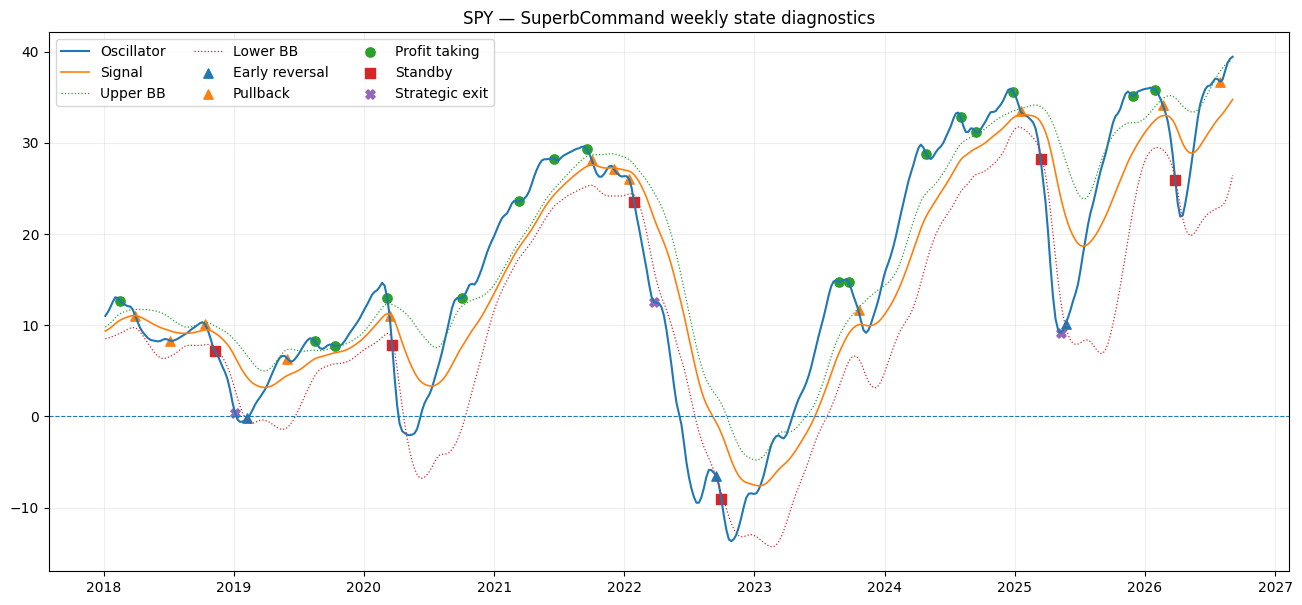

In [10]:

# ============================================================
# 2.10 — DIAGNOSTIC CHART
# ============================================================
PLOT_TICKER="SPY"
PLOT_START="2018-01-01"

s=signals[PLOT_TICKER].loc[PLOT_START:].copy()

fig,ax=plt.subplots(figsize=(16,7))
ax.plot(s.index,s["oscillator"],label="Oscillator",linewidth=1.5)
ax.plot(s.index,s["signal_line"],label="Signal",linewidth=1.2)
ax.plot(s.index,s["upper_bb"],label="Upper BB",linewidth=.9,linestyle=":")
ax.plot(s.index,s["lower_bb"],label="Lower BB",linewidth=.9,linestyle=":")
ax.axhline(0,linewidth=.8,linestyle="--")

for col,marker,label in [
    ("start_early_reversal","^","Early reversal"),
    ("start_pullback","^","Pullback"),
    ("start_profit_taking","o","Profit taking"),
    ("standby_anchor_event","s","Standby"),
    ("position_exit_event","X","Strategic exit"),
]:
    q=s[s[col]]
    ax.scatter(q.index,q["oscillator"],marker=marker,s=45,label=label)

ax.set_title(f"{PLOT_TICKER} — SuperbCommand weekly state diagnostics")
ax.legend(ncol=3)
ax.grid(alpha=.2)
plt.show()



## 2.11 Integrity checks

Notebook 02 validates structural invariants rather than asking whether the strategy is profitable.

Examples:

- no 2026 observations;
- standby and active accumulation/profit-taking zones cannot coexist;
- only one zone mode can exist at a time;
- a strategic entry occurs through Early Reversal;
- strategic exit leaves the position out;
- all saved signal rows correspond to the locked research period.

These tests are especially important because the Pine logic contains persistent state and one-shot setup memory.


In [11]:
# ============================================================
# 2H.11 — HOLDOUT SIGNAL-EXTENSION VALIDATION
# ============================================================
checks={}
dates = panel.index.get_level_values("date")

checks["signal_panel_nonempty"]=len(panel)>0
checks["pre_2026_history_present"]=bool((dates<=RESEARCH_END_FROZEN).any())
checks["2026_holdout_present"]=bool((dates>=HOLDOUT_START).any())
checks["all_markets_processed"]=set(signals)==set(tickers)
checks["zone_modes_valid"]=all(s["zone_mode"].isin([0,1,2,3]).all() for s in signals.values())
checks["standby_suppresses_zones"]=all(
    not ((s["standby_active"])&(s["zone_mode"]!=0)).any() for s in signals.values()
)
checks["early_entries_are_ER"]=all(
    not (s["position_entry_event"] & ~s["start_early_reversal"]).any() for s in signals.values()
)
checks["exit_leaves_position_out"]=all(
    not (s.loc[s["position_exit_event"],"position_held"]).any() for s in signals.values()
)
checks["signal_file_written"]=SIGNAL_PATH.exists()

v=pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
print(v.to_string(index=False))

if not all(checks.values()):
    raise RuntimeError("Notebook 02H validation failed: "+str([k for k,v in checks.items() if not v]))

print("\n"+"="*78)
print("NOTEBOOK 02H STATUS: PASS")
print("="*78)
print("Frozen SuperbCommand engine extended through:", dates.max().date())
print("2026 HOLDOUT SIGNALS: ACCESSED FOR EVALUATION")
print("Parameters/logic changed: NO")
print("Proceed to Notebook 18.")

                   check  passed
   signal_panel_nonempty    True
pre_2026_history_present    True
    2026_holdout_present    True
   all_markets_processed    True
        zone_modes_valid    True
standby_suppresses_zones    True
    early_entries_are_ER    True
exit_leaves_position_out    True
     signal_file_written    True

NOTEBOOK 02H STATUS: PASS
Frozen SuperbCommand engine extended through: 2026-09-04
2026 HOLDOUT SIGNALS: ACCESSED FOR EVALUATION
Parameters/logic changed: NO
Proceed to Notebook 18.


In [12]:
# ============================================================
# 2H.12 — WRITE HOLDOUT SIGNAL MANIFEST
# ============================================================
manifest={
    "notebook_id":"02H",
    "notebook_name":"Frozen Signal Engine Extension Through 2026",
    "project_name":"SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc":datetime.now(timezone.utc).isoformat(),
    "research_end_frozen":str(RESEARCH_END_FROZEN.date()),
    "holdout_start":str(HOLDOUT_START.date()),
    "holdout_accessed":True,
    "latest_signal_date":str(panel.index.get_level_values("date").max().date()),
    "frequency":"weekly (W-FRI)",
    "parameters":PARAMS,
    "parameters_changed":False,
    "signal_logic_changed":False,
    "markets_processed":tickers,
    "signal_output":str(SIGNAL_PATH),
    "pre_2026_backup_dir":str(BACKUP_DIR),
    "status":"PASS",
}
mp=PATHS["manifests"]/"02H_2026_frozen_signal_extension_manifest.json"
with open(mp,"w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2)
print("Saved:",mp)

Saved: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/02H_2026_frozen_signal_extension_manifest.json



---

# End of Notebook 02

## Outputs

- `data/raw/prototype_yahoo_ohlc_adjusted.parquet`
- `data/processed/superbcommand_weekly_signal_panel.parquet`
- `results/02_superbcommand_event_summary.csv`
- `manifests/02_superbcommand_signal_engine_manifest.json`

## Next: Notebook 03 — Signal Diagnostics

Notebook 03 should **not yet optimise a trading strategy**. It should ask whether the states generated here contain economically meaningful information about subsequent returns across horizons, markets and asset classes.

That will be the first empirical test of whether SuperbCommand's structure generalises beyond the markets on which it was originally developed.
